In [1]:
print("Hello WOrld")

Hello WOrld


In [2]:
import sys
from pathlib import Path
cwd = Path.cwd()
for candidate in (cwd, cwd.parent):
    if (candidate / "helpers" / "common.py").exists() and str(candidate) not in sys.path:
        sys.path.append(str(candidate))
        break

## For this one, i set the temp=0
from helpers.common import together_ai_llm, langfuse, langfuse_handler

/home/yash/Desktop/Code/1. Langchain and Ollama/lang_ollama_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Setup the DB

In [3]:
from langchain_community.utilities import SQLDatabase
db = SQLDatabase.from_uri("sqlite:///employees_db-full-1.0.6.db")
db.dialect
db.get_usable_table_names()

try:
    tables = db.get_usable_table_names()
    print("✓ Database connected successfully")
    print(f"✓ Found {len(tables)} tables: {', '.join(tables)}")
    
except Exception as e:
    print(f"✗ Database connection failed: {e}")

db.run("Select count(*) from employees")
SCHEMA = db.get_table_info()

✓ Database connected successfully
✓ Found 6 tables: departments, dept_emp, dept_manager, employees, salaries, titles


#### Setup Tools

In [4]:
from langchain.tools import tool

@tool
def get_database_schema(table_name: str = None) -> str:
    """Get database schema information for SQL query generation.
    Use this first to understand table structure before creating queries."""
    print(f"Getting schema for: {table_name if table_name else 'all tables'}")
    
    if table_name:
        try:
            tables = db.get_usable_table_names()
            if table_name.lower() in [t.lower() for t in tables]:
                result = db.get_table_info([table_name])
                print(f"✓ Retrieved schema for table: {table_name}")
                return result
            else:
                return f"Error: Table '{table_name}' not found. Available tables: {', '.join(tables)}"
        except Exception as e:
            return f"Error getting table info: {e}"
    else:
        print("✓ Retrieved full database schema")
        return SCHEMA
get_database_schema.invoke({'table_name': "dept_emp"})
get_database_schema.invoke({})

Getting schema for: dept_emp
✓ Retrieved schema for table: dept_emp
Getting schema for: all tables
✓ Retrieved full database schema


'\nCREATE TABLE departments (\n\tdept_no CHAR(4) NOT NULL, \n\tdept_name VARCHAR(40) NOT NULL, \n\tPRIMARY KEY (dept_no), \n\tUNIQUE (dept_name)\n)\n\n/*\n3 rows from departments table:\ndept_no\tdept_name\nd009\tCustomer Service\nd005\tDevelopment\nd002\tFinance\n*/\n\n\nCREATE TABLE dept_emp (\n\temp_no INTEGER NOT NULL, \n\tdept_no CHAR(4) NOT NULL, \n\tfrom_date DATE NOT NULL, \n\tto_date DATE NOT NULL, \n\tPRIMARY KEY (emp_no, dept_no), \n\tFOREIGN KEY(dept_no) REFERENCES departments (dept_no), \n\tFOREIGN KEY(emp_no) REFERENCES employees (emp_no)\n)\n\n/*\n3 rows from dept_emp table:\nemp_no\tdept_no\tfrom_date\tto_date\n10001\td005\t1986-06-26\t9999-01-01\n10002\td007\t1996-08-03\t9999-01-01\n10003\td004\t1995-12-03\t9999-01-01\n*/\n\n\nCREATE TABLE dept_manager (\n\tdept_no CHAR(4) NOT NULL, \n\temp_no INTEGER NOT NULL, \n\tfrom_date DATE NOT NULL, \n\tto_date DATE NOT NULL, \n\tPRIMARY KEY (emp_no, dept_no), \n\tFOREIGN KEY(dept_no) REFERENCES departments (dept_no), \n\tFOREIG

In [ ]:

@tool
def generate_sql_query(question: str, schema_info: str = None) -> str:
    """Generate a SQL SELECT query from a natural language question using database schema.
    Always use this after getting schema information."""
    print(f"Generating SQL for: {question[:100]}...")
    
    schema_to_use = schema_info if schema_info else SCHEMA
    
    prompt = f"""
                Based on this database schema:
                {schema_to_use}

                Generate a SQL query to answer this question: {question}

                Rules:
                - Use only SELECT statements
                - Include only existing columns and tables
                - Add appropriate WHERE, GROUP BY, ORDER BY clauses as needed
                - Limit results to 10 rows unless specified otherwise
                - Use proper SQL syntax for SQLite

                Return only the SQL query, nothing else.
                """
    
    try:
        response = together_ai_llm.invoke(prompt)
        query = response.content.strip()
        print("Generated SQL query")
        return query
    except Exception as e:
        return f"Error generating query: {e}"

result = generate_sql_query.invoke({"question": "what is maximum salary in employees"})
print(result)

In [6]:
db.run(result)

''

In [6]:
import re

@tool
def validate_sql_query(query: str) -> str:
    """Validate SQL query for safety and syntax before execution.
    Returns 'Valid: <query>' if safe or 'Error: <message>' if unsafe."""
    print(f"🔍 Validating SQL: {query[:100]}...")
    
    # Clean up the query
    clean_query = query.strip()
    
    # Remove SQL code block markers if present
    clean_query = re.sub(r'```sql\s*', '', clean_query, flags=re.IGNORECASE)
    clean_query = re.sub(r'```\s*', '', clean_query)
    clean_query = clean_query.strip().rstrip(";")
    
    # Check 1: Must be a SELECT statement
    if not clean_query.lower().startswith("select"):
        return "Error: Only SELECT statements are allowed"
    
    # Check 2: Block dangerous SQL keywords
    dangerous_keywords = ['INSERT', 'UPDATE', 'DELETE', 'ALTER', 'DROP', 'CREATE', 'TRUNCATE']
    query_upper = clean_query.upper()
    
    for keyword in dangerous_keywords:
        if keyword in query_upper:
            return f"Error: {keyword} operations are not allowed"
    
    print("✓ Query validation passed")
    return f"Valid: {clean_query}"
validate_sql_query.invoke({"query": "SELECT MAX(salary) AS max_salary"})
# validate_sql_query.invoke({"query": "DELETE MAX(salary) AS max_salary"})

🔍 Validating SQL: SELECT MAX(salary) AS max_salary...
✓ Query validation passed


'Valid: SELECT MAX(salary) AS max_salary'

In [7]:

@tool
def execute_sql_query(query: str) -> str:
    """Execute a validated SQL query and return results.
    Only use this after validating the query for safety."""
    print(f"Executing SQL: {query[:100]}...")
    
    try:
        clean_query = query.strip()
        if clean_query.startswith("Valid: "):
            clean_query = clean_query[7:]  # Remove "Valid: " prefix
        
        clean_query = re.sub(r'```sql\s*', '', clean_query, flags=re.IGNORECASE)
        clean_query = re.sub(r'```\s*', '', clean_query)
        clean_query = clean_query.strip().rstrip(";")
        
        result = db.run(clean_query)
        print("Query executed successfully")
        
        if result:
            return f"Query Results:\n{result}"
        else:
            return "Query executed successfully but returned no results."
            
    except Exception as e:
        error_msg = f"Execution Error: {str(e)}"
        print(f"✗ {error_msg}")
        return error_msg
execute_sql_query.invoke({"query": "SELECT MAX(salary) FROM salaries;"})

Executing SQL: SELECT MAX(salary) FROM salaries;...
Query executed successfully


'Query Results:\n[(158220,)]'

In [8]:
@tool
def fix_sql_error(original_query: str, error_message: str, question: str) -> str:
    """Fix a failed SQL query by analyzing the error and generating a corrected version.
    Use this when validation or execution fails."""
    print(f"Fixing SQL error: {error_message[:100]}...")
    
    fix_prompt = f"""
                    The following SQL query failed:
                    Query: {original_query}
                    Error: {error_message}
                    Original Question: {question}

                    Database Schema:
                    {SCHEMA}

                    Analyze the error and provide a corrected SQL query that:
                    1. Fixes the specific error mentioned
                    2. Still answers the original question
                    3. Uses only valid table and column names from the schema
                    4. Follows SQLite syntax rules

                    Return only the corrected SQL query, nothing else.
                    """
    
    try:
        response = together_ai_llm.invoke(fix_prompt)
        fixed_query = response.content.strip()
        print("✓ Generated fixed SQL query")
        return fixed_query
    except Exception as e:
        return f"Error generating fix: {e}"

fix_sql_error.invoke({"original_query": "Update MAX(salary) FROM salaries;", "error_message": "Error: Only SELECT statements are allowed", "question": "what is maximum salary in employees"})

Fixing SQL error: Error: Only SELECT statements are allowed...
✓ Generated fixed SQL query


'SELECT MAX(salary) AS max_salary FROM salaries;'

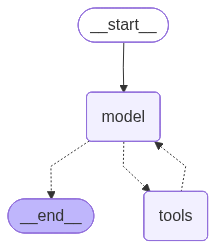

In [9]:
from langchain.agents import create_agent
SQL_SYSTEM_PROMPT = f"""You are an expert SQL analyst working with an employees database.

Database Schema:
{SCHEMA}

Your workflow for answering questions:
1. Use `get_database_schema` first to understand available tables and columns (if needed)
2. Use `generate_sql_query` to create SQL based on the question
3. Use `validate_sql_query` to check the query for safety and syntax
4. Use `execute_sql_query` to run the validated query
5. If there's an error, use `fix_sql_error` to correct it and try again (up to 3 times)
6. Provide a clear answer based on the query results

Rules:
- Always follow the workflow step by step
- If a query fails, use the fix tool and try again
- Provide clear, informative answers
- Be precise with table and column names
- Handle errors gracefully and try to fix them
- If you fail after 3 attempts, explain what went wrong

Available tools for each step:
- get_database_schema: Get table structure info
- generate_sql_query: Create SQL from question
- validate_sql_query: Check query safety/syntax  
- execute_sql_query: Run the query
- fix_sql_error: Fix failed queries

Remember: Always validate queries before executing them for safety.
"""

tools = [
    get_database_schema,
    generate_sql_query,
    validate_sql_query, 
    execute_sql_query,
    fix_sql_error
]

sql_agent = create_agent(
    together_ai_llm, 
    tools, 
    system_prompt=SQL_SYSTEM_PROMPT
)

sql_agent

In [10]:
def ask_sql(question: str):
    """Ask the SQL agent a question using the full workflow."""
    print(f"\n{'='*60}")
    print(f"SQL AGENT - Question: {question}")
    print('='*60)
    
    for event in sql_agent.stream({"messages": question},stream_mode="values", config={"callbacks": [langfuse_handler], "run_name": "text-to-sql"},):
        msg = event["messages"][-1]
        
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"\n🔧 Using Tool: {tc['name']}")
                print(f"Args: {str(tc['args'])[:200]}")
        
        elif hasattr(msg, 'content') and msg.content:
            print(f"\n💬 Answer:\n{msg.content}")


### Ask Question

In [12]:
ask_sql("What is the average salary of employees in the Sales department?")
# ask_sql("What is the total count of employees?")


SQL AGENT - Question: What is the average salary of employees in the Sales department?

💬 Answer:
What is the average salary of employees in the Sales department?

🔧 Using Tool: get_database_schema
Args: {'table_name': None}

🔧 Using Tool: generate_sql_query
Args: {'question': 'What is the average salary of employees in the Sales department?', 'schema_info': '(schema info from get_database_schema)'}

🔧 Using Tool: generate_sql_query
Args: {'question': 'What is the average salary of employees in the Sales department?', 'schema_info': '(schema info from get_database_schema)'}

🔧 Using Tool: validate_sql_query
Args: {'query': "SELECT AVG(s.salary) AS avg_salary\nFROM departments d\nJOIN dept_emp de ON d.dept_no = de.dept_no\nJOIN salaries s ON de.emp_no = s.emp_no\nWHERE d.dept_name = 'Sales' AND s.to_date = '999

🔧 Using Tool: execute_sql_query
Args: {'query': "SELECT AVG(s.salary) AS avg_salary\nFROM departments d\nJOIN dept_emp de ON d.dept_no = de.dept_no\nJOIN salaries s ON de.emp_n

In [13]:
db.run("SELECT COUNT(*) from employees")

'[(300024,)]'